
>>> Evaluare pentru: Cu Zgomot
         C      gamma    Acuratețe
   0.03125    0.00003       0.4934
   0.03125    0.00012       0.4934
   0.03125    0.00049       0.4934
   0.03125    0.00195       0.4934
   0.03125    0.00781       0.4934
   0.03125    0.03125       0.4934
   0.03125    0.12500       0.4934
   0.03125    0.50000       0.4934
   0.03125    2.00000       0.5132
   0.03125    8.00000       0.5149
     0.125    0.00003       0.4934
     0.125    0.00012       0.4934
     0.125    0.00049       0.4934
     0.125    0.00195       0.4934
     0.125    0.00781       0.5066
     0.125    0.03125       0.5017
     0.125    0.12500       0.5099
     0.125    0.50000       0.5248
     0.125    2.00000       0.5198
     0.125    8.00000       0.5149
       0.5    0.00003       0.4934
       0.5    0.00012       0.4934
       0.5    0.00049       0.5165
       0.5    0.00195       0.5099
       0.5    0.00781       0.5050
       0.5    0.03125       0.5033
       0.5    0.12500  

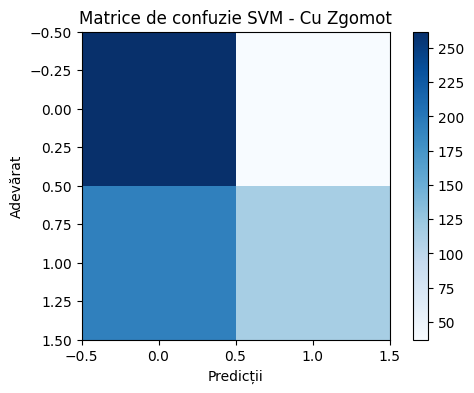


>>> Evaluare pentru: Fără Zgomot
         C      gamma    Acuratețe
   0.03125    0.00003       0.4868
   0.03125    0.00012       0.4868
   0.03125    0.00049       0.4868
   0.03125    0.00195       0.4868
   0.03125    0.00781       0.4868
   0.03125    0.03125       0.4868
   0.03125    0.12500       0.4868
   0.03125    0.50000       0.4868
   0.03125    2.00000       0.4868
   0.03125    8.00000       0.4868
     0.125    0.00003       0.4868
     0.125    0.00012       0.4868
     0.125    0.00049       0.4868
     0.125    0.00195       0.4868
     0.125    0.00781       0.4868
     0.125    0.03125       0.5264
     0.125    0.12500       0.4868
     0.125    0.50000       0.4868
     0.125    2.00000       0.4868
     0.125    8.00000       0.5000
       0.5    0.00003       0.4868
       0.5    0.00012       0.4868
       0.5    0.00049       0.4868
       0.5    0.00195       0.5314
       0.5    0.00781       0.5363
       0.5    0.03125       0.5264
       0.5    0.12500

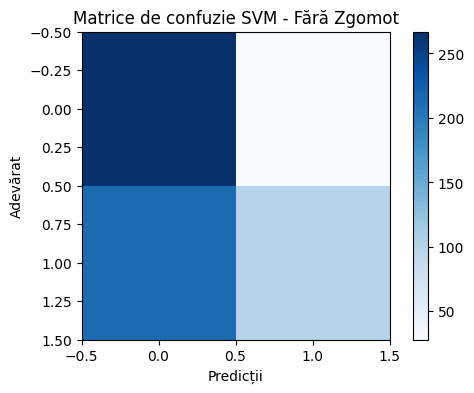

In [5]:
# Importul bibliotecilor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from itertools import product

# Baza de date
url_train_noise = "https://archive.ics.uci.edu/ml/machine-learning-databases/hill-valley/Hill_Valley_with_noise_Training.data"
url_test_noise = "https://archive.ics.uci.edu/ml/machine-learning-databases/hill-valley/Hill_Valley_with_noise_Testing.data"
url_train_clean = "https://archive.ics.uci.edu/ml/machine-learning-databases/hill-valley/Hill_Valley_without_noise_Training.data"
url_test_clean = "https://archive.ics.uci.edu/ml/machine-learning-databases/hill-valley/Hill_Valley_without_noise_Testing.data"

# Încărcare date
df_train_noise = pd.read_csv(url_train_noise)
df_test_noise = pd.read_csv(url_test_noise)
df_train_clean = pd.read_csv(url_train_clean)
df_test_clean = pd.read_csv(url_test_clean)

def procesare_si_evaluare(df_train, df_test, titlu=""):
    X_train = df_train.iloc[:, :-1].values
    y_train = df_train.iloc[:, -1].values
    X_test = df_test.iloc[:, :-1].values
    y_test = df_test.iloc[:, -1].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    C_values = [2**i for i in range(-5, 8, 2)]         # C = 2^-5 până la 2^7
    gamma_values = [2**i for i in range(-15, 4, 2)]    # gamma = 2^-15 până la 2^3

    best_accuracy = 0
    best_params = (None, None)

    print(f"\n>>> Evaluare pentru: {titlu}")
    print(f"{'C':>10} {'gamma':>10} {'Acuratețe':>12}")

    # Iterăm prin toate combinațiile de C și gamma
    for C, gamma in product(C_values, gamma_values):
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # Afișăm fiecare combinație testată
        print(f"{C:>10} {gamma:>10.5f} {acc:>12.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_params = (C, gamma)

    # Afișăm cei mai buni parametri
    print(f"\n[{titlu}] Cea mai bună acuratețe: {best_accuracy:.4f} cu C={best_params[0]}, gamma={best_params[1]}")

    # Evaluare model optim
    model_final = SVC(kernel='rbf', C=best_params[0], gamma=best_params[1])
    model_final.fit(X_train, y_train)
    y_pred = model_final.predict(X_test)

    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Matricea de confuzie:\n", conf_matrix)

    # Vizualizare matrice de confuzie
    plt.figure(figsize=(6, 4))
    plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
    plt.colorbar()
    plt.xlabel("Predicții")
    plt.ylabel("Adevărat")
    plt.title(f"Matrice de confuzie SVM - {titlu}")
    plt.show()

# Apelăm separat pentru fiecare set și combinațiile lor
procesare_si_evaluare(df_train_noise, df_test_noise, "Cu Zgomot")
procesare_si_evaluare(df_train_clean, df_test_clean, "Fără Zgomot")
